# TSP – Travelling Salesman Problem

## Representación del problema

El TSP se modela como un **grafo completo y ponderado** $G = (V, E, w)$:

| Concepto | Representación |
|---|---|
| Ciudades | Nodos del grafo |
| Conexión entre ciudades | Aristas (el grafo es **completo**) |
| Distancia | Peso de cada arista |
| Solución | Ciclo hamiltoniano de peso mínimo |

En código usamos:
- `ciudades: dict[str, (x, y)]` — coordenadas de cada ciudad
- `distancias: dict[(str, str), float]` — distancia euclídea entre cada par

## Algoritmo implementado

### Fase 1 – Vecino más cercano (greedy constructivo)
Construye la ruta visitando siempre la ciudad no visitada más cercana. Es $O(n^2)$ y da una solución inicial razonable (suele estar dentro del 20-25 % del óptimo).

### Fase 2 – 2-opt (mejora local)
Detecta cruces en la ruta e invierte el segmento entre los dos puntos que se cruzan. Itera hasta que ningún intercambio mejore la distancia total. Cada iteración es $O(n^2)$.

```
Ruta original:  ... A → B → ... → C → D ...
Tras 2-opt:     ... A → C → ... → B → D ...
                        (segmento BC invertido)
```

In [19]:
import sys, os

# Sube 2 niveles: P1_TSP -> Taller1 -> USFQ-Wshop
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Verificación
print("ROOT:", ROOT)
print("Existe Taller1:", os.path.exists(os.path.join(ROOT, 'Taller1')))

%matplotlib inline
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 50

ROOT: c:\Users\ferna\Desktop\Maestria\Inteligencia Artificial\Taller\Taller 1\USFQ-Wshop
Existe Taller1: True


## Importaciones

In [20]:
from Taller1.P1_TSP.util import generar_ciudades_con_distancias, calcular_distancia_ruta
from Taller1.P1_TSP.TSP import TSP, _dist

## Caso 1 – 10 ciudades (animación completa con etiquetas)

In [21]:
N = 10
ciudades, distancias = generar_ciudades_con_distancias(N)
tsp = TSP(ciudades, distancias)

print(f"Ciudades generadas: {list(ciudades.keys())}")
print(f"Número de distancias en la tabla: {len(distancias)}  (= {N}×{N-1})")

Ciudades generadas: ['B4', 'D0', 'K0', 'K3', 'Y1', 'A5', 'B1', 'A4', 'I7', 'K8']
Número de distancias en la tabla: 90  (= 10×9)


  Ciudades          : 10
  Pasos greedy      : 10
  Pasos 2-opt       : 2
  Distancia inicial : 588.52
  Distancia final   : 570.70


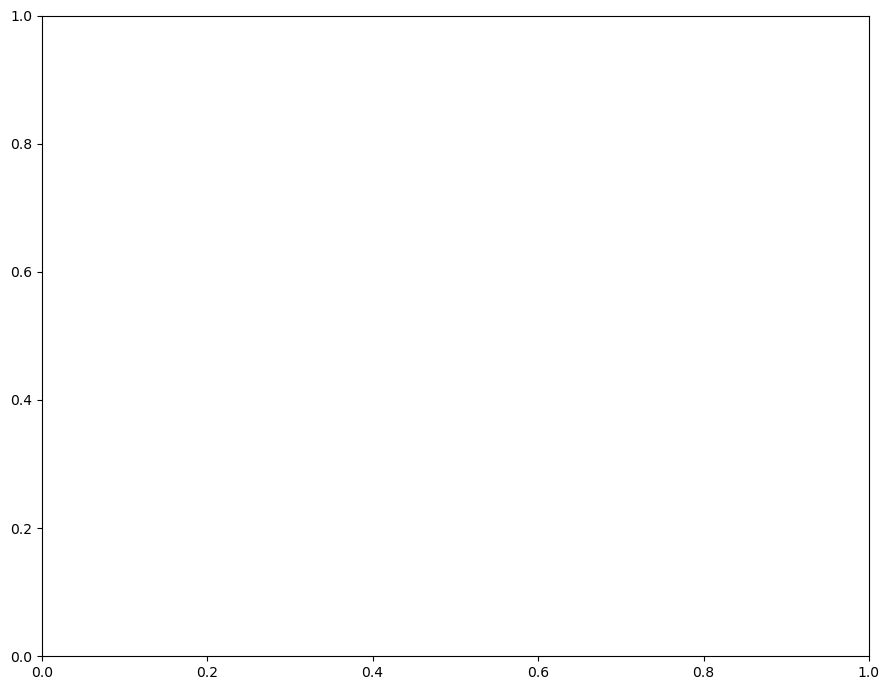

In [22]:
# --- Resolver con animación ---
# La animación muestra:
#   · Azul  → construcción greedy (vecino más cercano)
#   · Rojo  → mejora 2-opt
ruta_optima = tsp.resolver_con_animacion(intervalo_ms=600, mostrar_anotaciones=True)

In [23]:
print("Ruta óptima encontrada:")
print(" → ".join(ruta_optima) + f" → {ruta_optima[0]}")
print(f"Distancia total: {calcular_distancia_ruta(ciudades, ruta_optima):.2f}")

Ruta óptima encontrada:
B4 → K0 → B1 → A5 → K8 → Y1 → A4 → I7 → D0 → K3 → B4
Distancia total: 570.70


## Visualización estática del resultado final

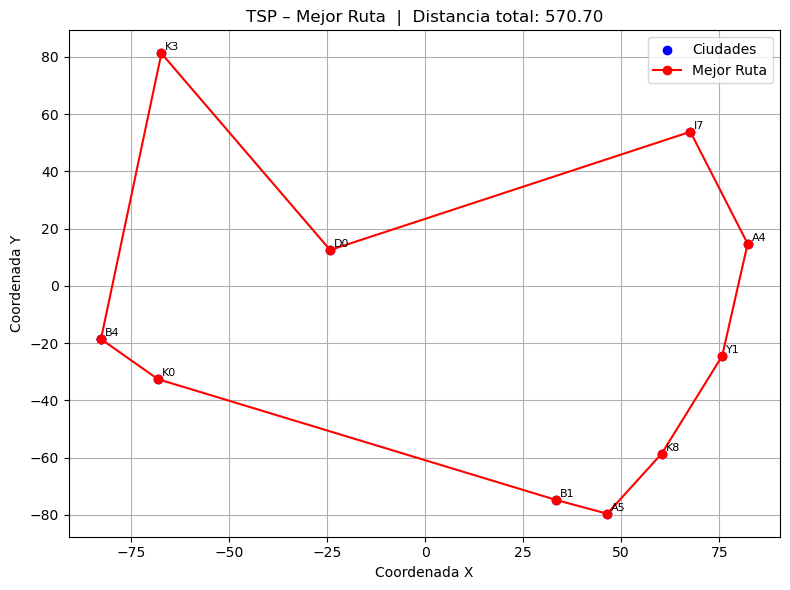

In [24]:
tsp.plotear_resultado(ruta_optima, mostrar_anotaciones=True)

## Caso 2 – 100 ciudades

  Ciudades          : 82
  Pasos greedy      : 82
  Pasos 2-opt       : 30
  Distancia inicial : 1850.11
  Distancia final   : 1537.99


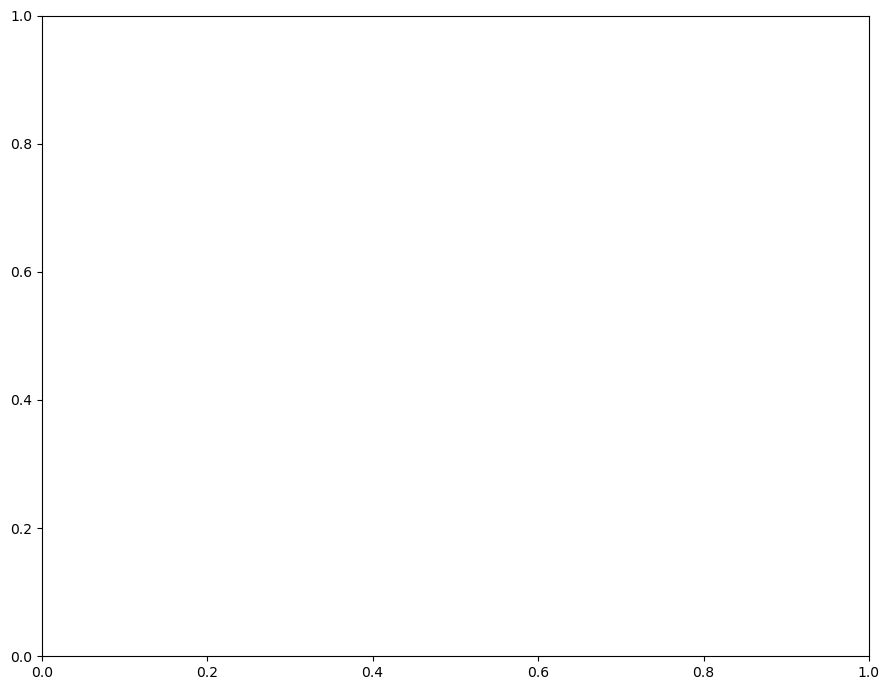

In [25]:
N = 100
ciudades_100, distancias_100 = generar_ciudades_con_distancias(N)
tsp_100 = TSP(ciudades_100, distancias_100)
ruta_100 = tsp_100.resolver_con_animacion(intervalo_ms=60, mostrar_anotaciones=False)

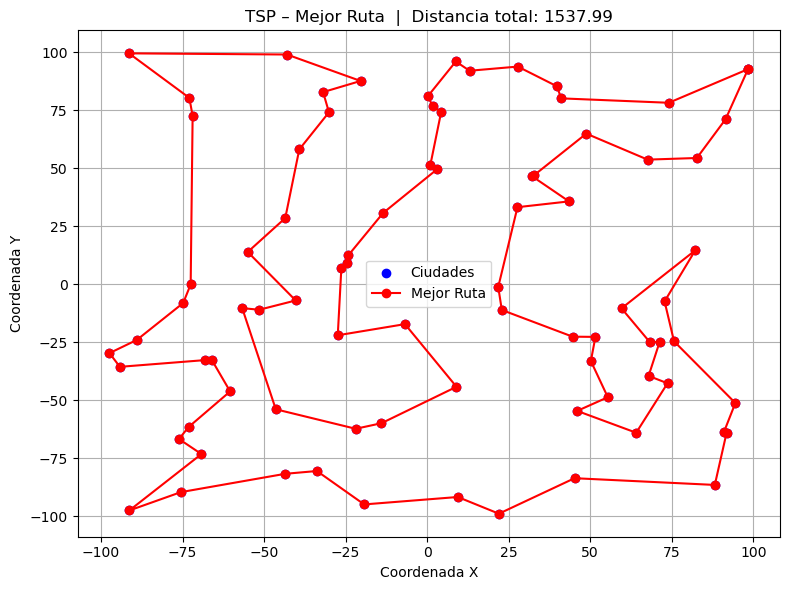

In [26]:
tsp_100.plotear_resultado(ruta_100, mostrar_anotaciones=False)

## Comparación: ruta aleatoria vs optimizada

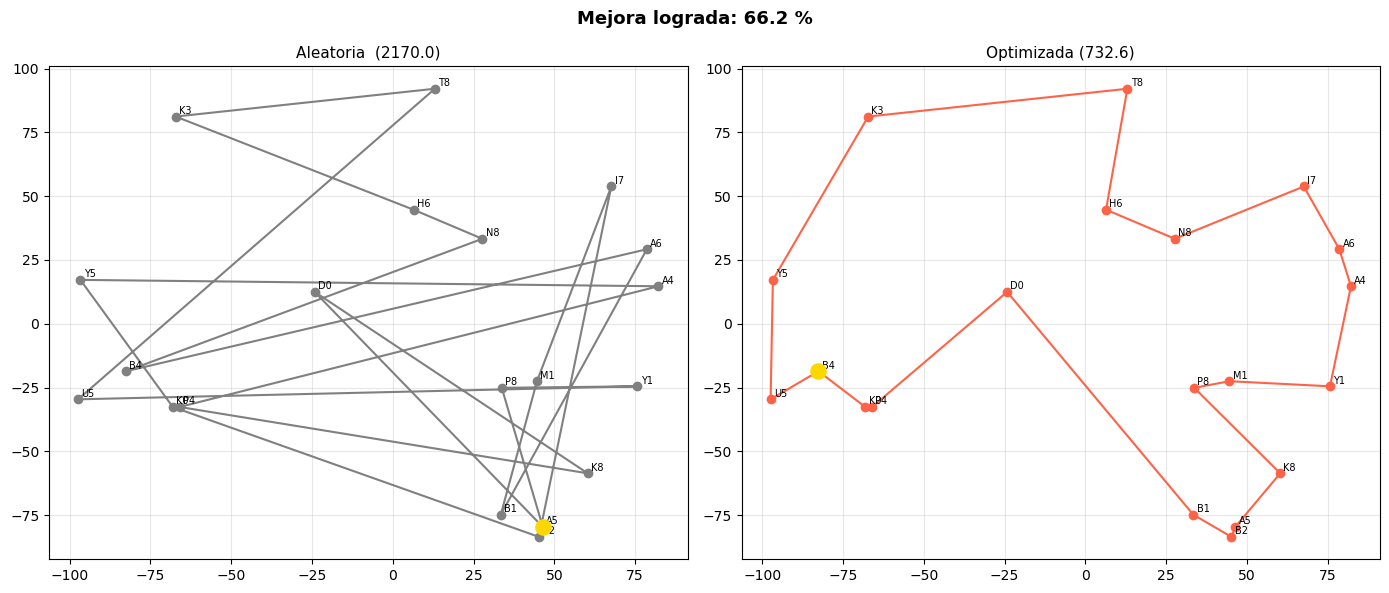

Distancia aleatoria : 2169.98
Distancia optimizada: 732.56
Mejora              : 66.2 %


In [27]:
import random
import matplotlib.pyplot as plt

N = 20
ciudades_cmp, distancias_cmp = generar_ciudades_con_distancias(N)
tsp_cmp = TSP(ciudades_cmp, distancias_cmp)

nombres = list(ciudades_cmp.keys())
ruta_aleatoria = nombres[:]
random.shuffle(ruta_aleatoria)
ruta_opt = tsp_cmp.encontrar_la_ruta_mas_corta()

dist_aleatoria = calcular_distancia_ruta(ciudades_cmp, ruta_aleatoria)
dist_opt = calcular_distancia_ruta(ciudades_cmp, ruta_opt)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, ruta, titulo, color in [
    (axes[0], ruta_aleatoria, f'Aleatoria  ({dist_aleatoria:.1f})', 'gray'),
    (axes[1], ruta_opt,       f'Optimizada ({dist_opt:.1f})', 'tomato'),
]:
    xs = [ciudades_cmp[c][0] for c in ruta] + [ciudades_cmp[ruta[0]][0]]
    ys = [ciudades_cmp[c][1] for c in ruta] + [ciudades_cmp[ruta[0]][1]]
    ax.plot(xs, ys, '-o', color=color, linewidth=1.5)
    ax.scatter([xs[0]], [ys[0]], color='gold', s=120, zorder=5)
    for c in ruta:
        ax.text(ciudades_cmp[c][0]+1, ciudades_cmp[c][1]+1, c, fontsize=7)
    ax.set_title(titulo, fontsize=11)
    ax.grid(True, alpha=0.3)

mejora = (dist_aleatoria - dist_opt) / dist_aleatoria * 100
fig.suptitle(f'Mejora lograda: {mejora:.1f} %', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"Distancia aleatoria : {dist_aleatoria:.2f}")
print(f"Distancia optimizada: {dist_opt:.2f}")
print(f"Mejora              : {mejora:.1f} %")